# Experiment: Shannon Information Entropy

In [1]:
import sys
import os
project_root = "" # set the root path
sys.path.insert(0, project_root)

import json
import torch
import h5py
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
from functions.helper import batch_wise_random_drop, obs_field_reconstruction, sampler_test_data_generator, sampler_checkpoint_load, sampler_training_visualizer
device = [i for i in range(torch.cuda.device_count())][0]
# torch.manual_seed(128)

In [2]:
secnario = "SHM"

In [3]:
stage = 2
obs_sample = 4096
K = 200
mode = "closest" # ["latest","best","closest"] # Latest - best for testing in training progress; Closest - best for sampling after training process
path = os.listdir("../output/")[next((i for i, p in enumerate(os.listdir("../output/")) if secnario in str(p)), None)]
path = f"../output/{path}"

-> Field Inversion Checkpoint loaded: output/SHM-2025-12-28-04-58-41/checkpoints/stage_2_4096.pt
-> Dataloader: target shape = torch.Size([1, 1, 64, 64]) | observation shape = torch.Size([1, 4096, 7]) | dropped_observation shape = torch.Size([1, 4096, 7])


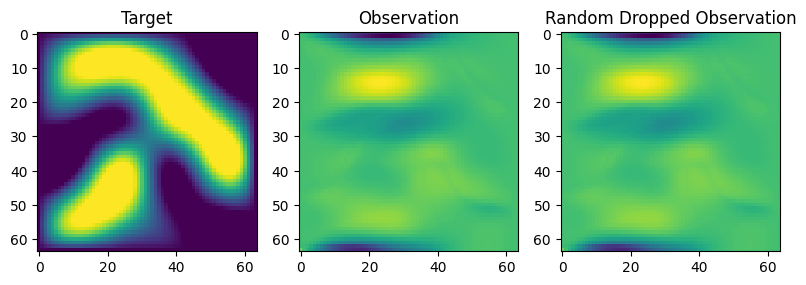

In [4]:
model, certainty_param = sampler_checkpoint_load(path, stage, obs_sample, mode, device)
target, obs, drop_obs,_,_,_ = sampler_test_data_generator(path, stage, obs_sample, mode, device)
drop_obs_batch = drop_obs.repeat(K, 1, 1)

In [5]:
img = model.sample(shape=(K,1,64,64), steps=80, device="cuda", conditions=torch.zeros_like(drop_obs_batch))
prior_samples = img.squeeze(1)

In [6]:
with h5py.File(f"Outputs/Prior-Samples {secnario}.h5", "w") as f:
    f.create_dataset("Prior",data = prior_samples.detach().cpu().numpy())